# Análisis exploratorio del riesgo crediticio en LendingClub

## Introducción

Este proyecto estudia datos históricos de préstamos de LendingClub concedidos entre 2007 y 2010. En el crédito al consumo, evaluar el riesgo supone comprender tanto las características de quienes solicitan financiación como las condiciones de los préstamos y sus resultados observados.

El objetivo de este análisis exploratorio es comprender la estructura y calidad de los datos e identificar asociaciones entre las características de los prestatarios y de los préstamos y el pago completo. La variable objetivo, **not.fully.paid**, vale 1 cuando el préstamo no fue pagado completamente y 0 cuando sí lo fue. No representa una causa ni una predicción.

El conjunto contiene información sobre política de crédito, finalidad, tipo de interés, cuota, ingresos declarados, endeudamiento, puntuación FICO, historial de crédito y consultas o incidencias crediticias. Las observaciones describen préstamos individuales del periodo 2007–2010.

El EDA es una fase descriptiva: las diferencias y relaciones que se presenten son asociaciones observadas, no efectos causales. No se entrenarán modelos ni se corregirá el posible desbalance de la variable objetivo en este notebook.

## Análisis

Se cargarán las librerías de análisis y el archivo CSV existente. La ruta se resolverá desde la carpeta del proyecto o desde la carpeta del notebook, sin crear ni modificar el conjunto de datos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from scipy import stats

SEED = 42
TARGET = "not.fully.paid"
NUMERIC_FEATURES = [
    "int.rate", "installment", "log.annual.inc", "dti", "fico",
    "days.with.cr.line", "revol.bal", "revol.util",
    "inq.last.6mths", "delinq.2yrs", "pub.rec",
]
OUTCOME_LABELS = {0: "Pagado completamente", 1: "No pagado completamente"}
SPANISH_LABELS = {
    "int.rate": "Tipo de interés",
    "installment": "Cuota mensual",
    "log.annual.inc": "Logaritmo del ingreso anual",
    "dti": "Relación deuda-ingreso (DTI)",
    "fico": "Puntuación FICO",
    "days.with.cr.line": "Días con línea de crédito",
    "revol.bal": "Saldo de crédito rotativo",
    "revol.util": "Utilización del crédito rotativo",
    "inq.last.6mths": "Consultas de crédito en seis meses",
    "delinq.2yrs": "Moras en dos años",
    "pub.rec": "Registros públicos desfavorables",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.title_fontsize": 10,
    "figure.dpi": 110,
})

candidates = [
    Path.cwd() / "data" / "loan_data.csv",
    Path.cwd().parent / "data" / "loan_data.csv",
    Path.cwd().parent.parent / "data" / "loan_data.csv",
]
DATA_PATH = next((candidate.resolve() for candidate in candidates if candidate.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data/loan_data.csv desde la carpeta del proyecto o del notebook.")

loans = pd.read_csv(DATA_PATH)
required_columns = {
    "credit.policy", "purpose", *NUMERIC_FEATURES, TARGET,
}
missing_columns = sorted(required_columns.difference(loans.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas en el conjunto de datos: {missing_columns}")

print(f"Archivo cargado: {DATA_PATH}\nDimensiones: {loans.shape[0]:,} préstamos y {loans.shape[1]} variables.".replace(",", "."))
display(loans.head().style.set_caption("Primeras cinco observaciones"))
display(loans.tail().style.set_caption("Últimas cinco observaciones"))
display(pd.DataFrame({
    "Tipo de dato": loans.dtypes.astype(str),
    "Valores no nulos": loans.notna().sum(),
    "Valores únicos": loans.nunique(dropna=True),
}).rename_axis("Variable"))
general_info = pd.DataFrame({
    "Filas": [loans.shape[0]],
    "Variables": [loans.shape[1]],
    "Uso de memoria (bytes)": [int(loans.memory_usage(deep=True).sum())],
    "Variables numéricas": [loans.select_dtypes(include="number").shape[1]],
    "Variables categóricas": [loans.select_dtypes(exclude="number").shape[1]],
})
display(general_info.style.set_caption("Información general del conjunto"))
description = loans.describe(include="all").T.rename(columns={
    "count": "Casos",
    "unique": "Categorías únicas",
    "top": "Valor más frecuente",
    "freq": "Frecuencia del valor más frecuente",
    "mean": "Media",
    "std": "Desviación estándar",
    "min": "Mínimo",
    "25%": "Percentil 25",
    "50%": "Mediana",
    "75%": "Percentil 75",
    "max": "Máximo",
})
display(description.rename_axis("Variable"))


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.118900,829.100000,11.350407,19.480000,737,5639.958333,28854,52.100000,0,0,0,0
1,1,credit_card,0.107100,228.220000,11.082143,14.290000,707,2760.000000,33623,76.700000,0,0,0,0
2,1,debt_consolidation,0.135700,366.860000,10.373491,11.630000,682,4710.000000,3511,25.600000,1,0,0,0
3,1,debt_consolidation,0.100800,162.340000,11.350407,8.100000,712,2699.958333,33667,73.200000,1,0,0,0
4,1,credit_card,0.142600,102.920000,11.299732,14.970000,667,4066.000000,4740,39.500000,0,1,0,0


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.146100,344.760000,12.180755,10.390000,672,10474.000000,215372,82.100000,2,0,0,1
9574,0,all_other,0.125300,257.700000,11.141862,0.210000,722,4380.000000,184,1.100000,5,0,0,1
9575,0,debt_consolidation,0.107100,97.810000,10.596635,13.090000,687,3450.041667,10036,82.900000,8,0,0,1
9576,0,home_improvement,0.160000,351.580000,10.819778,19.180000,692,1800.000000,0,3.200000,5,0,0,1
9577,0,debt_consolidation,0.139200,853.430000,11.264464,16.280000,732,4740.000000,37879,57.000000,6,0,0,1


,Tipo de dato,Valores no nulos,Valores únicos
Variable,,,
credit.policy,int64,9578,2
purpose,str,9578,7
int.rate,float64,9578,249
installment,float64,9578,4788
log.annual.inc,float64,9578,1987
dti,float64,9578,2529
fico,int64,9578,44
days.with.cr.line,float64,9578,2687
revol.bal,int64,9578,7869


,Filas,Variables,Uso de memoria (bytes),Variables numéricas,Variables categóricas
0,9578,14,1600274,13,1


,Casos,Categorías únicas,Valor más frecuente,Frecuencia del valor más frecuente,Media,Desviación estándar,Mínimo,Percentil 25,Mediana,Percentil 75,Máximo
Variable,,,,,,,,,,,
credit.policy,"9,578.000",NaN,NaN,NaN,0.805,0.396,0.000,1.000,1.000,1.000,1.000
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,"9,578.000",NaN,NaN,NaN,0.123,0.027,0.060,0.104,0.122,0.141,0.216
installment,"9,578.000",NaN,NaN,NaN,319.089,207.071,15.670,163.770,268.950,432.762,940.140
log.annual.inc,"9,578.000",NaN,NaN,NaN,10.932,0.615,7.548,10.558,10.929,11.291,14.528
dti,"9,578.000",NaN,NaN,NaN,12.607,6.884,0.000,7.213,12.665,17.950,29.960
fico,"9,578.000",NaN,NaN,NaN,710.846,37.971,612.000,682.000,707.000,737.000,827.000
days.with.cr.line,"9,578.000",NaN,NaN,NaN,"4,560.767","2,496.930",178.958,"2,820.000","4,139.958","5,730.000","17,639.958"
revol.bal,"9,578.000",NaN,NaN,NaN,"16,913.964","33,756.190",0.000,"3,187.000","8,596.000","18,249.500","1,207,359.000"


El conjunto analizado reúne **9.578 préstamos y 14 variables** que describen las condiciones del crédito, el perfil financiero del prestatario y el resultado observado. Esta amplitud permite caracterizar los préstamos de LendingClub incluidos en el archivo, pero no garantiza que los patrones sean representativos de otros periodos, entidades o poblaciones. La inspección de tipos y rangos ofrece el contexto necesario para interpretar correctamente las tablas posteriores; las incidencias de completitud y consistencia se evalúan específicamente en la sección de calidad.


## Calidad de los datos y descripción de variables

### Análisis

Se cuantificarán los valores faltantes, las filas duplicadas, los tipos y la cardinalidad categórica. También se comprobarán reglas de plausibilidad explícitas y se señalarán valores extremos mediante el criterio del rango intercuartílico (RIC). Las alertas no implican eliminación de registros.

Para cada comprobación se mostrarán recuentos y porcentajes sobre el total de observaciones. Cuando exista una incidencia, se propondrá una estrategia para valorar en una fase posterior, sin aplicarla aquí.

In [2]:
n_rows = len(loans)
missing_table = pd.DataFrame({
    "Casos": loans.isna().sum(),
    "Porcentaje": loans.isna().mean().mul(100),
})
missing_table = missing_table.loc[missing_table["Casos"].gt(0)].sort_values("Casos", ascending=False)
if missing_table.empty:
    display(pd.DataFrame({"Casos": [0], "Porcentaje": [0.0]}, index=["Sin valores nulos"]))
else:
    display(missing_table.rename_axis("Variable"))
    affected = ", ".join(missing_table.index)

duplicate_count = int(loans.duplicated().sum())
duplicate_pct = duplicate_count / n_rows * 100 if n_rows else 0
display(pd.DataFrame({
    "Casos": [duplicate_count],
    "Porcentaje de filas": [duplicate_pct],
}, index=["Filas duplicadas exactas"]))

categorical_columns = loans.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cardinality_table = pd.DataFrame({
    "Tipo": loans.dtypes.astype(str),
    "Valores únicos": loans.nunique(dropna=True),
    "Porcentaje de valores distintos": loans.nunique(dropna=True).div(max(n_rows, 1)).mul(100),
})
display(cardinality_table.rename_axis("Variable"))
if categorical_columns:
    display(pd.DataFrame({
        "Categorías observadas": loans[categorical_columns].nunique(dropna=True),
        "Valores": loans[categorical_columns].apply(
            lambda column: ", ".join(sorted(column.dropna().astype(str).unique()))
        ),
    }).rename_axis("Variable"))

checks = []
def add_check(name, mask, strategy):
    count = int(pd.Series(mask, index=loans.index).fillna(False).sum())
    checks.append({
        "Comprobación": name,
        "Casos": count,
        "Porcentaje": count / max(n_rows, 1) * 100,
        "Tratamiento propuesto si procede": strategy,
    })

add_check("Objetivo fuera de {0, 1}", ~loans[TARGET].isin([0, 1]), "Verificar etiquetas en el origen; no recodificar sin conocer su significado.")
add_check("credit.policy fuera de {0, 1}", ~loans["credit.policy"].isin([0, 1]), "Contrastar con la definición del indicador antes de corregir o excluir.")
known_purposes = {
    "credit_card", "debt_consolidation", "educational", "major_purchase",
    "small_business", "all_other", "home_improvement",
}
add_check("Finalidad vacía o no reconocida", loans["purpose"].isna() | ~loans["purpose"].astype("string").isin(known_purposes), "Revisar las etiquetas originales; agrupar categorías solo con justificación.")
add_check("Tipo de interés fuera de [0, 1]", ~loans["int.rate"].between(0, 1), "Confirmar si se almacena como proporción; corregir unidades solo con evidencia del origen.")
add_check("Cuota no positiva", loans["installment"].le(0), "Validar contra el contrato y distinguir errores de registros especiales.")
add_check("Ingreso logarítmico no finito", ~np.isfinite(loans["log.annual.inc"]), "Revisar el dato de ingreso original antes de transformar o imputar.")
add_check("DTI negativo", loans["dti"].lt(0), "Validar la definición y el registro; no truncar automáticamente.")
add_check("FICO fuera del rango de referencia 300–850", ~loans["fico"].between(300, 850), "Contrastar con el rango de origen y la versión de la puntuación.")
add_check("Días con línea de crédito negativos", loans["days.with.cr.line"].lt(0), "Revisar el dato de origen; no sustituir por cero sin evidencia.")
add_check("Saldo rotativo negativo", loans["revol.bal"].lt(0), "Comprobar unidades, devoluciones y captura antes de tratar.")
add_check("Utilización rotativa fuera de 0–100", ~loans["revol.util"].between(0, 100), "Comprobar la definición porcentual y los valores originales.")
for column in ["inq.last.6mths", "delinq.2yrs", "pub.rec"]:
    add_check(f"{column}: recuento negativo", loans[column].lt(0), "Validar el recuento contra la fuente y corregir solo con trazabilidad.")
quality_checks = pd.DataFrame(checks).set_index("Comprobación")
display(quality_checks)
issues = quality_checks.loc[quality_checks["Casos"].gt(0)]

numeric_for_outliers = NUMERIC_FEATURES.copy()
outlier_rows = []
for column in numeric_for_outliers:
    values = loans[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "Variable": column, "Límite inferior RIC": lower, "Límite superior RIC": upper,
        "Casos señalados": count, "Porcentaje de filas": count / max(n_rows, 1) * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).set_index("Variable").sort_values("Porcentaje de filas", ascending=False)
display(outlier_table)

variable_descriptions = pd.DataFrame([
    ("credit.policy", "Binaria", "Indica si el prestatario cumple los criterios de suscripción de crédito de LendingClub (1: sí; 0: no)."),
    ("purpose", "Categórica nominal", "Finalidad declarada del préstamo; identifica grupos sin orden inherente."),
    ("int.rate", "Continua", "Tipo de interés del préstamo expresado como proporción; por ejemplo, 0,11 equivale a 11%."),
    ("installment", "Continua", "Cuota mensual debida si se financia el préstamo."),
    ("log.annual.inc", "Continua transformada", "Logaritmo natural del ingreso anual declarado por el prestatario."),
    ("dti", "Continua", "Relación deuda-ingreso del prestatario."),
    ("fico", "Discreta", "Puntuación FICO del prestatario."),
    ("days.with.cr.line", "Continua", "Antigüedad de la línea de crédito en días."),
    ("revol.bal", "Continua", "Saldo rotativo pendiente al cierre del ciclo de facturación de la tarjeta."),
    ("revol.util", "Continua", "Porcentaje de utilización del crédito rotativo disponible."),
    ("inq.last.6mths", "Discreta", "Número de consultas de crédito en los últimos seis meses."),
    ("delinq.2yrs", "Discreta", "Número de veces que el prestatario estuvo 30 días o más en mora durante los últimos dos años."),
    ("pub.rec", "Discreta", "Número de registros públicos desfavorables, como quiebras, gravámenes fiscales o sentencias."),
    ("not.fully.paid", "Binaria objetivo", "Vale 1 si el préstamo no se pagó completamente y 0 si se pagó completamente."),
], columns=["Variable", "Clasificación", "Significado"])
display(variable_descriptions.set_index("Variable"))


,Casos,Porcentaje
Sin valores nulos,0,0.000


,Casos,Porcentaje de filas
Filas duplicadas exactas,0,0.000


,Tipo,Valores únicos,Porcentaje de valores distintos
Variable,,,
credit.policy,int64,2,0.021
purpose,str,7,0.073
int.rate,float64,249,2.600
installment,float64,4788,49.990
log.annual.inc,float64,1987,20.745
dti,float64,2529,26.404
fico,int64,44,0.459
days.with.cr.line,float64,2687,28.054
revol.bal,int64,7869,82.157


,Categorías observadas,Valores
Variable,,
purpose,7,"all_other, credit_card, debt_consolidation, ed..."


,Casos,Porcentaje,Tratamiento propuesto si procede
Comprobación,,,
"Objetivo fuera de {0, 1}",0,0.000,Verificar etiquetas en el origen; no recodific...
"credit.policy fuera de {0, 1}",0,0.000,Contrastar con la definición del indicador ant...
Finalidad vacía o no reconocida,0,0.000,Revisar las etiquetas originales; agrupar cate...
"Tipo de interés fuera de [0, 1]",0,0.000,Confirmar si se almacena como proporción; corr...
Cuota no positiva,0,0.000,Validar contra el contrato y distinguir errore...
Ingreso logarítmico no finito,0,0.000,Revisar el dato de ingreso original antes de t...
DTI negativo,0,0.000,Validar la definición y el registro; no trunca...
FICO fuera del rango de referencia 300–850,0,0.000,Contrastar con el rango de origen y la versión...
Días con línea de crédito negativos,0,0.000,Revisar el dato de origen; no sustituir por ce...


,Límite inferior RIC,Límite superior RIC,Casos señalados,Porcentaje de filas
Variable,,,,
delinq.2yrs,0.000,0.000,1120,11.693
revol.bal,"-19,406.750","40,843.250",780,8.144
pub.rec,0.000,0.000,559,5.836
inq.last.6mths,-3.000,5.000,478,4.991
days.with.cr.line,"-1,545.000","10,095.000",346,3.612
log.annual.inc,9.459,12.391,238,2.485
installment,-239.719,836.251,236,2.464
int.rate,0.049,0.196,51,0.532
fico,599.500,819.500,6,0.063


,Clasificación,Significado
Variable,,
credit.policy,Binaria,Indica si el prestatario cumple los criterios ...
purpose,Categórica nominal,Finalidad declarada del préstamo; identifica g...
int.rate,Continua,Tipo de interés del préstamo expresado como pr...
installment,Continua,Cuota mensual debida si se financia el préstamo.
log.annual.inc,Continua transformada,Logaritmo natural del ingreso anual declarado ...
dti,Continua,Relación deuda-ingreso del prestatario.
fico,Discreta,Puntuación FICO del prestatario.
days.with.cr.line,Continua,Antigüedad de la línea de crédito en días.
revol.bal,Continua,Saldo rotativo pendiente al cierre del ciclo d...


### Calidad de los datos

En el archivo analizado no se observan **valores nulos ni filas duplicadas exactas**, y ninguna de las reglas de plausibilidad definidas detecta casos fuera de rango. Esto respalda la consistencia del conjunto respecto de las comprobaciones aplicadas, pero no descarta errores que dichas reglas no puedan detectar ni sustituye la validación con la fuente original.

El criterio de 1,5 × RIC señala **3.814 casos entre variables**. Este total no equivale a 3.814 préstamos distintos, porque una misma observación puede aparecer como extrema en más de una variable; además, un valor extremo no es necesariamente erróneo. Conviene conservar estos registros y comprobar la robustez de los análisis ante colas largas, especialmente en variables de recuento y saldos, antes de decidir cualquier tratamiento.


## Variable objetivo y finalidad del préstamo

### Análisis

Se calcularán las frecuencias absolutas y relativas de cada clase de not.fully.paid y la tasa observada de la clase 1 por finalidad. Los gráficos mostrarán tanto el volumen como la proporción, que responden a preguntas distintas.

El desbalance, si existe, afecta a la lectura de métricas futuras: una exactitud alta puede surgir al predecir siempre la clase mayoritaria y aun así no identificar adecuadamente la clase minoritaria. En esta fase no se reequilibran las clases ni se atribuyen relaciones causales.

,Frecuencia absoluta,Frecuencia relativa (%)
Clase,,
Pagado completamente,8045,83.995
No pagado completamente,1533,16.005


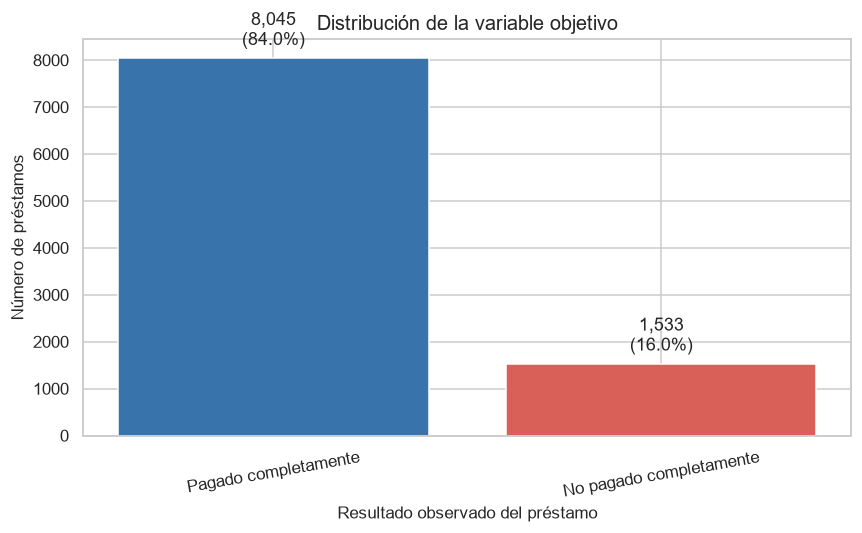

,Número de préstamos,Tasa no pagado completamente (%),Porcentaje del total (%)
purpose,,,
debt_consolidation,3957,15.239,41.313
all_other,2331,16.602,24.337
credit_card,1262,11.569,13.176
home_improvement,629,17.011,6.567
small_business,619,27.787,6.463
major_purchase,437,11.213,4.563
educational,343,20.117,3.581


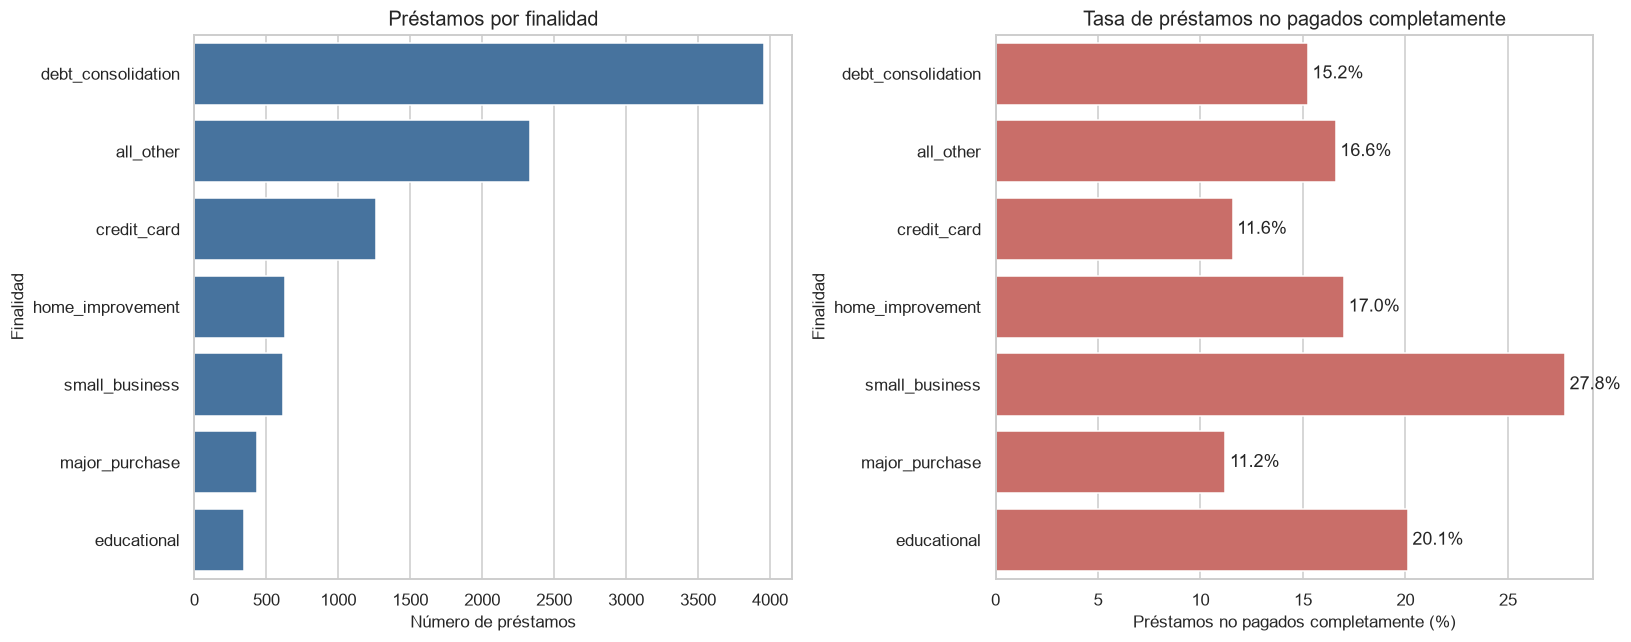

In [3]:
target_counts = loans[TARGET].value_counts().reindex([0, 1], fill_value=0)
target_summary = pd.DataFrame({
    "Clase": [OUTCOME_LABELS[label] for label in target_counts.index],
    "Frecuencia absoluta": target_counts.to_numpy(),
    "Frecuencia relativa (%)": target_counts.div(len(loans)).mul(100).to_numpy(),
}).set_index("Clase")
display(target_summary)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(target_summary.index, target_summary["Frecuencia absoluta"], color=["#3973ac", "#d95f59"])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Resultado observado del préstamo")
ax.set_ylabel("Número de préstamos")
for bar, pct in zip(bars, target_summary["Frecuencia relativa (%)"]):
    ax.annotate(f"{bar.get_height():,.0f}\n({pct:.1f}%)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

majority = int(target_counts.idxmax())
minority = int(target_counts.idxmin())
minority_pct = float(target_counts.div(len(loans)).loc[minority] * 100)
imbalance_ratio = float(target_counts.max() / target_counts.min()) if target_counts.min() else np.inf

purpose_summary = loans.groupby("purpose", observed=True)[TARGET].agg(
    prestamos="size", tasa_no_pagado="mean"
).sort_values("prestamos", ascending=False)
purpose_summary["porcentaje_prestamos"] = purpose_summary["prestamos"].div(len(loans)).mul(100)
purpose_summary["tasa_no_pagado"] = purpose_summary["tasa_no_pagado"].mul(100)
display(purpose_summary.rename(columns={
    "prestamos": "Número de préstamos",
    "porcentaje_prestamos": "Porcentaje del total (%)",
    "tasa_no_pagado": "Tasa no pagado completamente (%)",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
purpose_order = purpose_summary.index.tolist()
sns.barplot(data=purpose_summary.reset_index(), y="purpose", x="prestamos",
            order=purpose_order, color="#3973ac", ax=axes[0])
axes[0].set_title("Préstamos por finalidad")
axes[0].set_xlabel("Número de préstamos")
axes[0].set_ylabel("Finalidad")
sns.barplot(data=purpose_summary.reset_index(), y="purpose", x="tasa_no_pagado",
            order=purpose_order, color="#d95f59", ax=axes[1])
axes[1].set_title("Tasa de préstamos no pagados completamente")
axes[1].set_xlabel("Préstamos no pagados completamente (%)")
axes[1].set_ylabel("Finalidad")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

most_common_purpose = purpose_summary["prestamos"].idxmax()
highest_rate_purpose = purpose_summary["tasa_no_pagado"].idxmax()
lowest_rate_purpose = purpose_summary["tasa_no_pagado"].idxmin()


### IObjetivo y finalidad

La clase **no pagado completamente** representa el **16,0 %** de los préstamos (1.533 de 9.578), frente al 84,0 % que sí se pagó completamente. Por ello, un clasificador trivial que siempre predijera la clase mayoritaria obtendría cerca de un 84 % de exactitud sin identificar ningún impago: la exactitud, por sí sola, sería una medida engañosa.

La finalidad *debt_consolidation* concentra el mayor volumen (3.957 préstamos; 41,3 % del conjunto). La tasa observada de impago más alta corresponde a *small_business* (27,8 %) y la más baja a *major_purchase* (11,2 %). Estas tasas deben leerse junto con el tamaño de cada categoría: *small_business* reúne 619 casos y *major_purchase* 437. Las diferencias son descriptivas y no permiten atribuir un efecto causal a la finalidad del préstamo.


## Distribución de las variables numéricas

### Análisis

Para las once variables numéricas se calcularán media, desviación estándar, mediana, percentiles y asimetría. Los histogramas ofrecen una vista compacta de las distribuciones. Los valores extremos señalados por el RIC no se eliminan.

Las escalas y asimetrías pueden condicionar la comparación entre variables y el preprocesamiento posterior. Se usarán mediana y percentiles para describir distribuciones sesgadas y se separarán las variables de recuento de las mediciones continuas.

,Casos,Media,Desviación estándar,Mínimo,P5,P25,mediana,P75,P95,Máximo,asimetría
Variable,,,,,,,,,,,
int.rate,"9,578.000",0.123,0.027,0.060,0.077,0.104,0.122,0.141,0.167,0.216,0.164
installment,"9,578.000",319.089,207.071,15.670,65.559,163.770,268.950,432.762,756.265,940.140,0.913
log.annual.inc,"9,578.000",10.932,0.615,7.548,9.918,10.558,10.929,11.291,11.918,14.528,0.029
dti,"9,578.000",12.607,6.884,0.000,1.270,7.213,12.665,17.950,23.650,29.960,0.024
fico,"9,578.000",710.846,37.971,612.000,657.000,682.000,707.000,737.000,782.000,827.000,0.471
days.with.cr.line,"9,578.000","4,560.767","2,496.930",178.958,"1,320.042","2,820.000","4,139.958","5,730.000","9,329.958","17,639.958",1.156
revol.bal,"9,578.000","16,913.964","33,756.190",0.000,127.700,"3,187.000","8,596.000","18,249.500","57,654.300","1,207,359.000",11.161
revol.util,"9,578.000",46.799,29.014,0.000,1.100,22.600,46.300,70.900,94.000,119.000,0.060
inq.last.6mths,"9,578.000",1.577,2.200,0.000,0.000,0.000,1.000,2.000,5.000,33.000,3.584


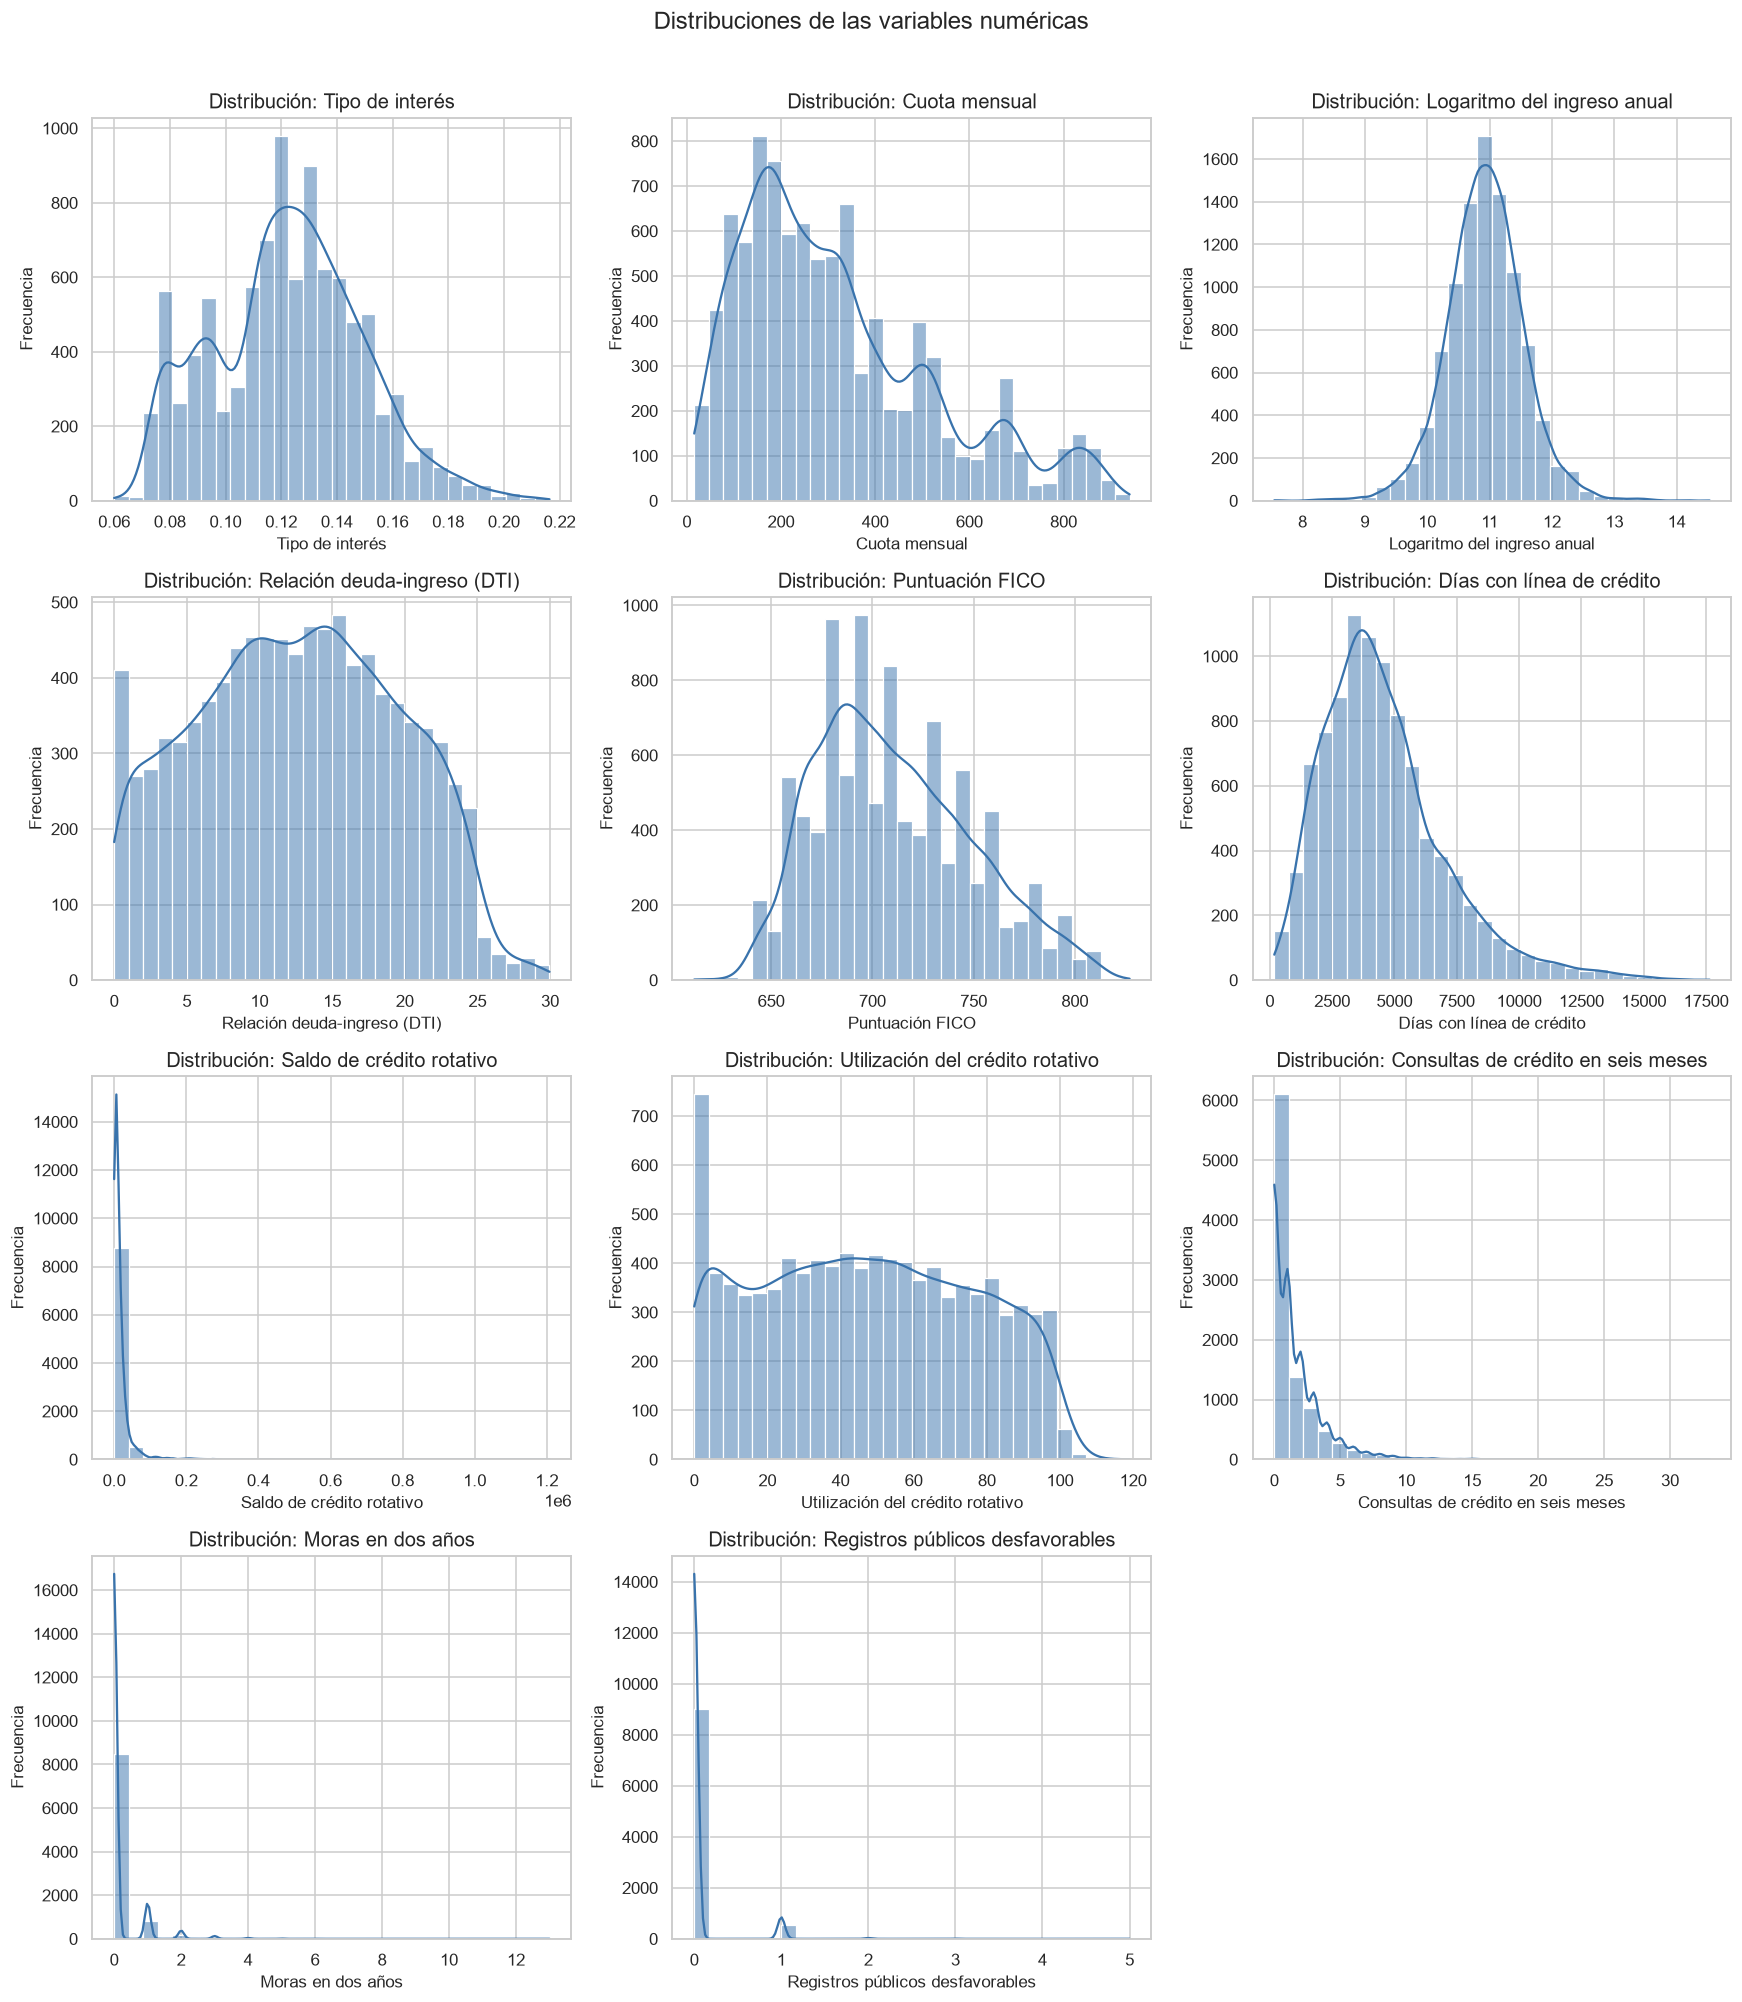

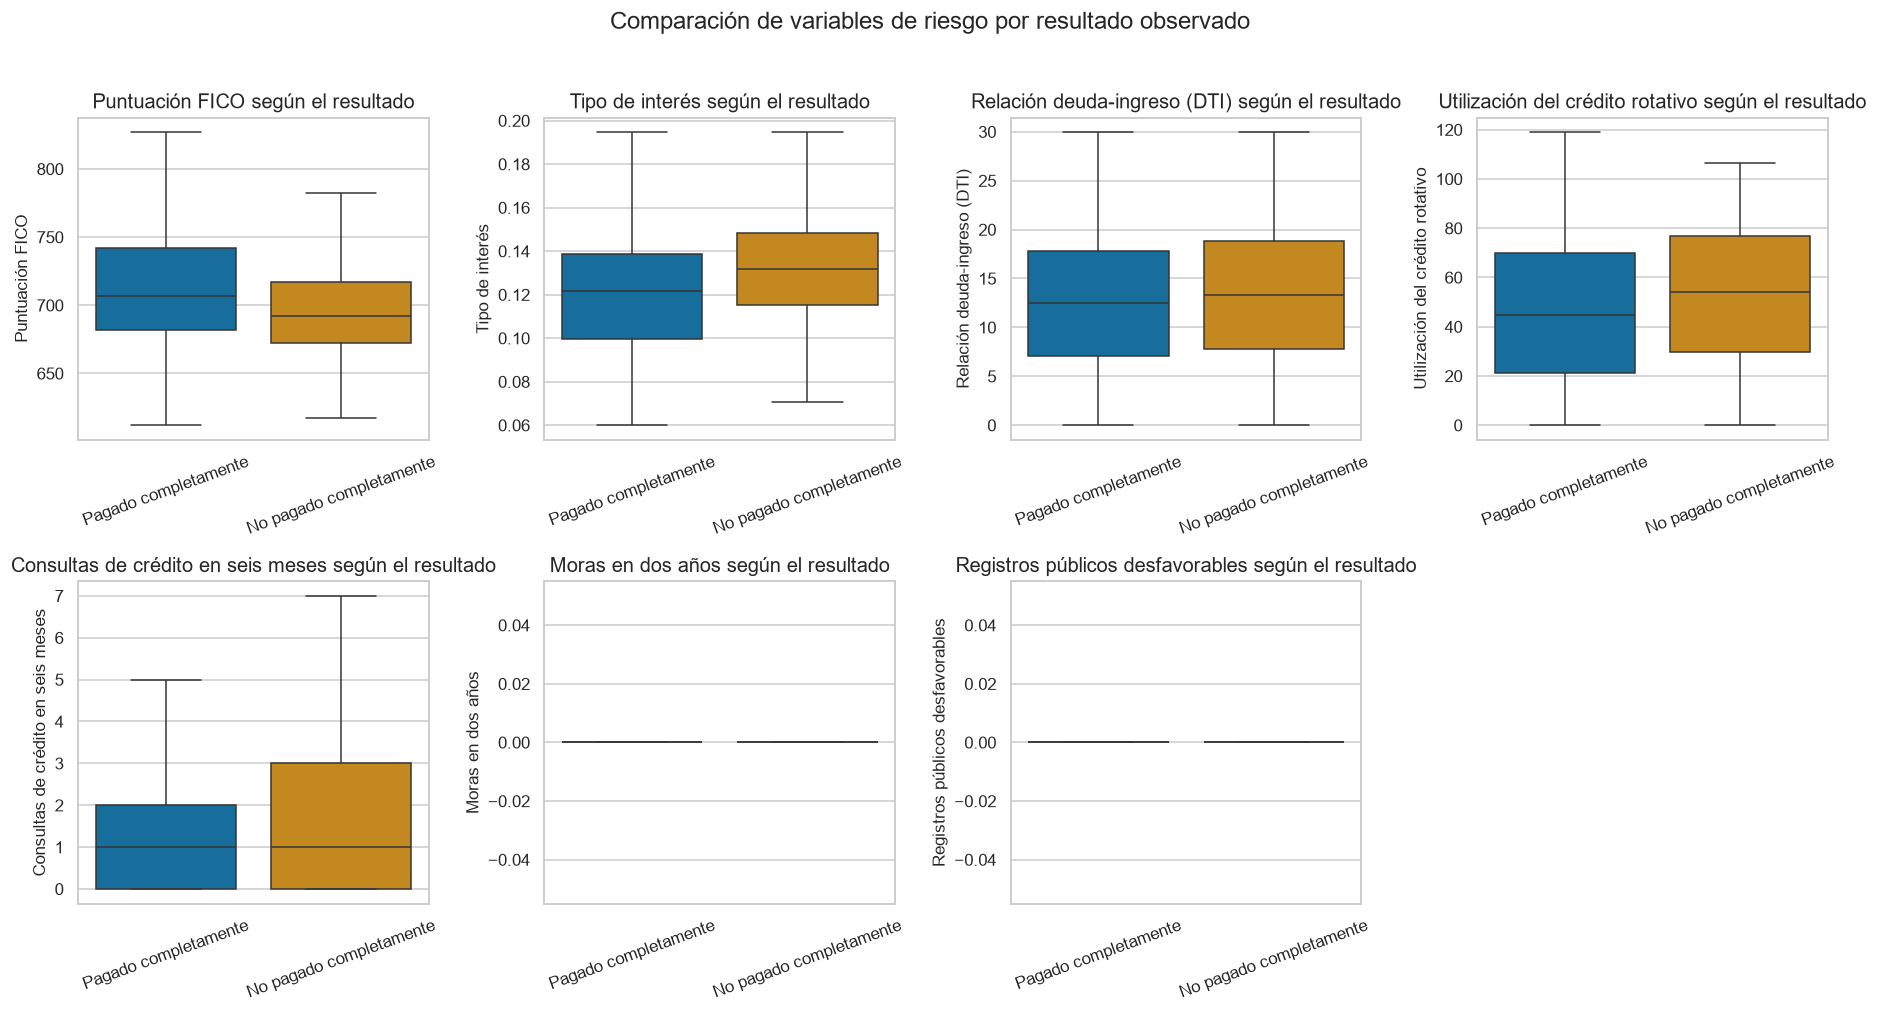

,Pagado completamente,No pagado completamente
Variable,,
int.rate,0.122,0.132
installment,266.520,287.310
log.annual.inc,10.933,10.878
dti,12.530,13.340
fico,707.000,692.000
days.with.cr.line,"4,140.042","4,050.000"
revol.bal,"8,535.000","8,850.000"
revol.util,44.800,53.900
inq.last.6mths,1.000,1.000


In [4]:
numeric_summary = loans[NUMERIC_FEATURES].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T
numeric_summary["mediana"] = loans[NUMERIC_FEATURES].median()
numeric_summary["asimetría"] = loans[NUMERIC_FEATURES].skew()
display(numeric_summary[[
    "count", "mean", "std", "min", "5%", "25%", "mediana", "75%", "95%", "max", "asimetría"
]].rename(columns={
    "count": "Casos", "mean": "Media", "std": "Desviación estándar", "min": "Mínimo",
    "5%": "P5", "25%": "P25", "75%": "P75", "95%": "P95", "max": "Máximo",
}).rename_axis("Variable"))

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for column, ax in zip(NUMERIC_FEATURES, axes.flat):
    sns.histplot(data=loans, x=column, bins=30, kde=True, ax=ax, color="#3973ac")
    ax.set_title(f"Distribución: {SPANISH_LABELS[column]}")
    ax.set_xlabel(SPANISH_LABELS[column])
    ax.set_ylabel("Frecuencia")
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Distribuciones de las variables numéricas", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

skewness = loans[NUMERIC_FEATURES].skew().sort_values(key=lambda values: values.abs(), ascending=False)
most_skewed = skewness.index[0]
most_skewed_value = float(skewness.iloc[0])
skew_label = "positiva" if most_skewed_value > 0 else "negativa"

plot_features = ["fico", "int.rate", "dti", "revol.util", "inq.last.6mths", "delinq.2yrs", "pub.rec"]
plot_data = loans[plot_features + [TARGET]].copy()
plot_data["Resultado"] = plot_data[TARGET].map(OUTCOME_LABELS)
fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for column, ax in zip(plot_features, axes.flat):
    sns.boxplot(data=plot_data, x="Resultado", y=column, hue="Resultado",
                showfliers=False, legend=False, ax=ax)
    ax.set_title(f"{SPANISH_LABELS[column]} según el resultado")
    ax.set_xlabel("")
    ax.set_ylabel(SPANISH_LABELS[column])
    ax.tick_params(axis="x", rotation=20)
for ax in axes.flat[len(plot_features):]:
    ax.set_visible(False)
fig.suptitle("Comparación de variables de riesgo por resultado observado", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

all_median_comparison = loans.groupby(TARGET, observed=True)[NUMERIC_FEATURES].median().T
all_median_comparison.columns = [OUTCOME_LABELS[int(label)] for label in all_median_comparison.columns]
display(all_median_comparison.rename_axis("Variable"))


### Variables numéricas

Las variables presentan escalas y distribuciones muy diferentes, por lo que no son directamente comparables en magnitud. El saldo rotativo ilustra la presencia de una cola extensa: su mediana es **8.596**, mientras que el máximo alcanza **1.207.359**. En este contexto, la mediana y los percentiles describen mejor el valor típico que la media aislada, y las observaciones extremas no deben eliminarse automáticamente.

Al comparar grupos, la mediana de FICO es **707** para los préstamos pagados completamente y **692** para los no pagados; para la utilización del crédito rotativo, las medianas son **44,8 %** y **53,9 %**, respectivamente. Son diferencias descriptivas coherentes con una posible asociación entre el perfil crediticio y el resultado, no evidencia de causalidad ni prueba de capacidad predictiva. Los diagramas de caja ocultan puntos extremos únicamente para facilitar su lectura; los datos se mantienen en los cálculos.


## FICO, tipo de interés y asociaciones entre variables

### Análisis específico de FICO

Se describirá la puntuación FICO, se comparará entre resultados y se calculará la tasa observada por intervalos explícitos: hasta 660, 661–700, 701–740, 741–780 y superior a 780. Estos intervalos son agrupaciones descriptivas para facilitar la visualización; no sustituyen la variable original.

### Análisis específico del tipo de interés

Se comparará el tipo de interés por resultado y se visualizará frente a FICO. La documentación del conjunto de datos indica que prestatarios considerados más arriesgados reciben tipos superiores; por tanto, una asociación entre interés y resultado puede reflejar criterios de asignación y composición del riesgo, y no demuestra causalidad.

### Relaciones y análisis multivariado

Se inspeccionará la correlación de Pearson entre variables numéricas y dos combinaciones relacionadas con el riesgo: FICO con interés y DTI con FICO, coloreadas por resultado. Se usará una muestra aleatoria reproducible solo para hacer legibles los diagramas de dispersión.

,Número de préstamos,Tasa no pagado completamente (%)
fico_interval,,
Hasta 660,489,30.879
661–700,3732,19.373
701–740,3127,15.286
741–780,1709,8.777
Más de 780,521,5.950


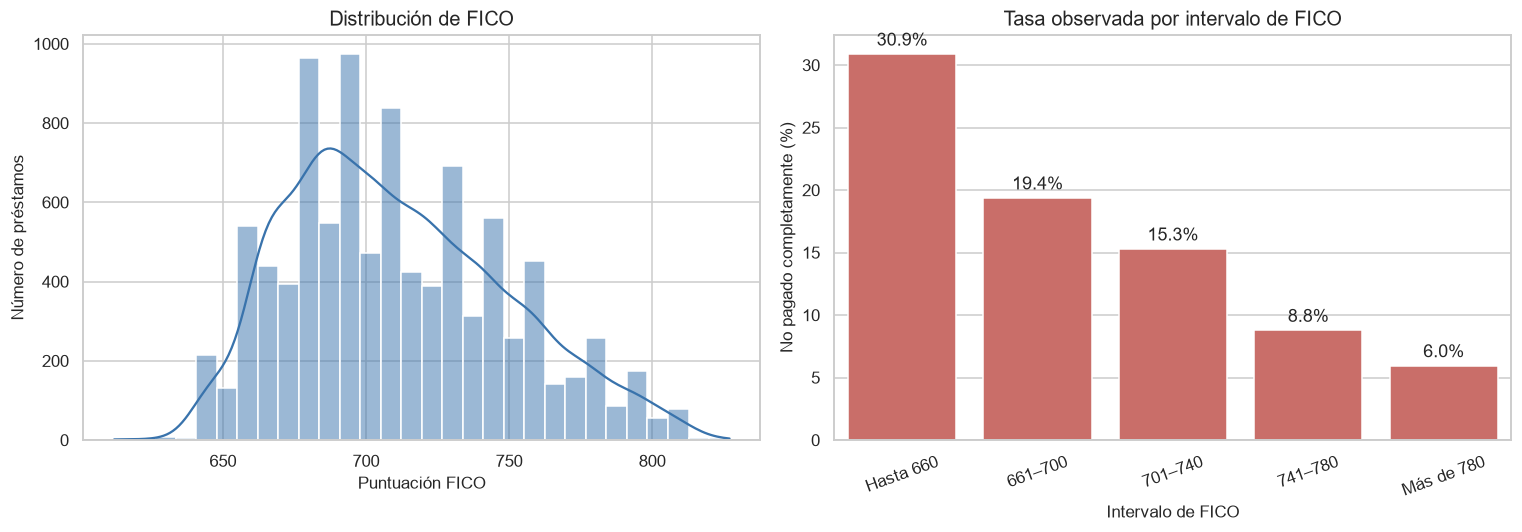

,Mediana de int.rate (%),Casos
not.fully.paid,,
Pagado completamente,12.180,8045
No pagado completamente,13.160,1533


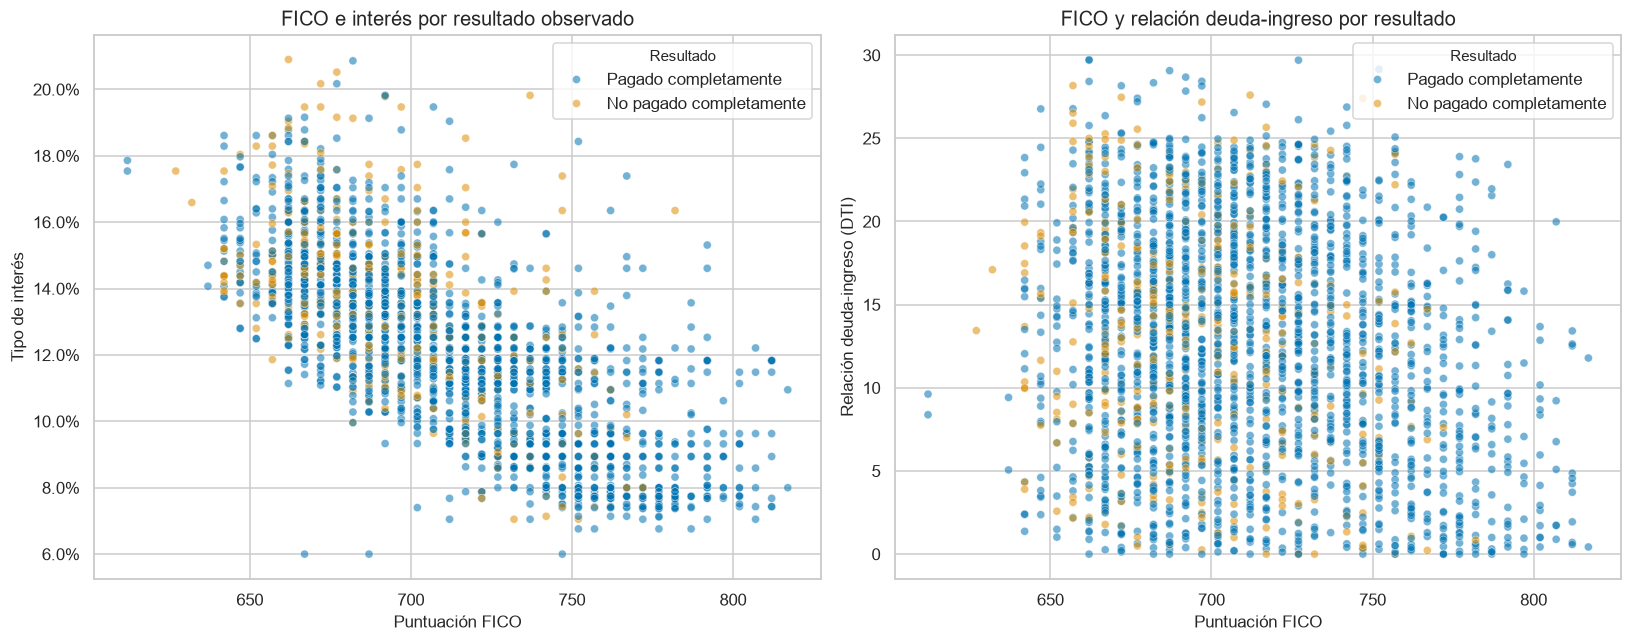

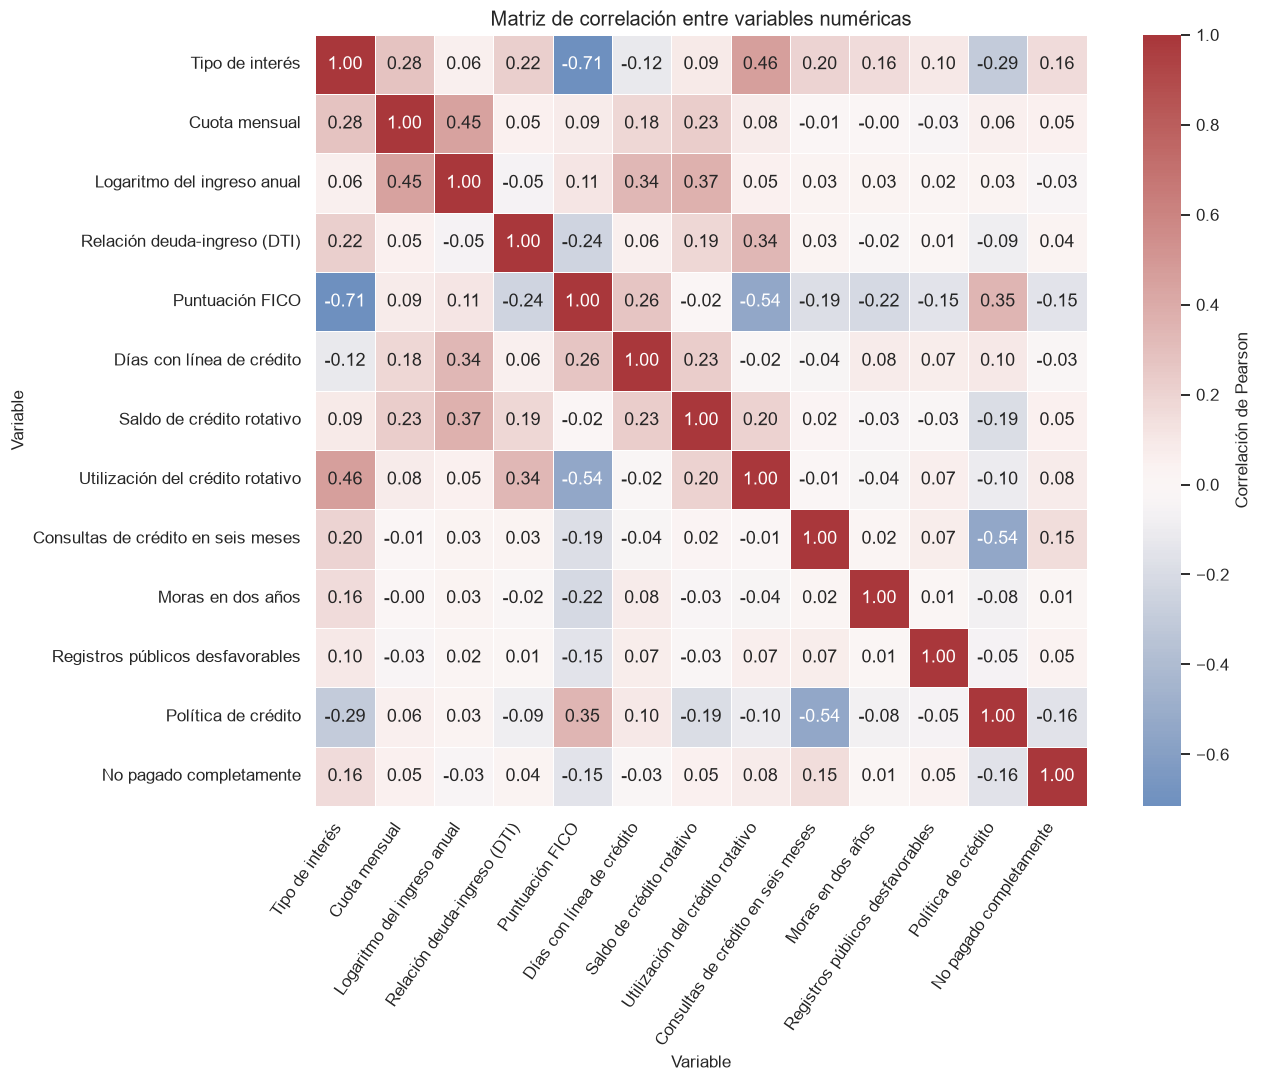

,,Correlación de Pearson
int.rate,fico,-0.715
fico,revol.util,-0.541
inq.last.6mths,credit.policy,-0.536
int.rate,revol.util,0.465
installment,log.annual.inc,0.448
log.annual.inc,revol.bal,0.372
fico,credit.policy,0.348
dti,revol.util,0.337


In [5]:
fico_edges = [-np.inf, 660, 700, 740, 780, np.inf]
fico_labels = ["Hasta 660", "661–700", "701–740", "741–780", "Más de 780"]
fico_data = loans.assign(fico_interval=pd.cut(
    loans["fico"], bins=fico_edges, labels=fico_labels, include_lowest=True
))
fico_rates = fico_data.groupby("fico_interval", observed=False)[TARGET].agg(
    prestamos="size", tasa_no_pagado="mean"
)
fico_rates["tasa_no_pagado"] = fico_rates["tasa_no_pagado"].mul(100)
display(fico_rates.rename(columns={
    "prestamos": "Número de préstamos",
    "tasa_no_pagado": "Tasa no pagado completamente (%)",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=loans, x="fico", bins=30, kde=True, color="#3973ac", ax=axes[0])
axes[0].set_title("Distribución de FICO")
axes[0].set_xlabel("Puntuación FICO")
axes[0].set_ylabel("Número de préstamos")
sns.barplot(data=fico_rates.reset_index(), x="fico_interval", y="tasa_no_pagado",
            color="#d95f59", ax=axes[1])
axes[1].set_title("Tasa observada por intervalo de FICO")
axes[1].set_xlabel("Intervalo de FICO")
axes[1].set_ylabel("No pagado completamente (%)")
axes[1].tick_params(axis="x", rotation=20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

fico_corr = float(loans["fico"].corr(loans[TARGET], method="spearman"))
nonempty_fico_rates = fico_rates.loc[fico_rates["prestamos"].gt(0), "tasa_no_pagado"]
fico_monotonic = bool(nonempty_fico_rates.is_monotonic_decreasing)

interest_medians = loans.groupby(TARGET, observed=True)["int.rate"].median()
rate0 = float(interest_medians.get(0, np.nan))
rate1 = float(interest_medians.get(1, np.nan))
fico_interest_corr = float(loans["fico"].corr(loans["int.rate"], method="spearman"))
display(pd.DataFrame({
    "Mediana de int.rate (%)": interest_medians.mul(100),
    "Casos": loans.groupby(TARGET, observed=True)["int.rate"].size(),
}).rename(index=OUTCOME_LABELS))

sample = loans.sample(n=min(2500, len(loans)), random_state=SEED)
sample = sample.assign(Resultado=sample[TARGET].map(OUTCOME_LABELS))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=sample, x="fico", y="int.rate", hue="Resultado",
                alpha=0.55, s=28, ax=axes[0])
axes[0].set_title("FICO e interés por resultado observado")
axes[0].set_xlabel("Puntuación FICO")
axes[0].set_ylabel("Tipo de interés")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1))
sns.scatterplot(data=sample, x="fico", y="dti", hue="Resultado",
                alpha=0.55, s=28, ax=axes[1])
axes[1].set_title("FICO y relación deuda-ingreso por resultado")
axes[1].set_xlabel("Puntuación FICO")
axes[1].set_ylabel("Relación deuda-ingreso (DTI)")
plt.tight_layout()
plt.show()

correlation_columns = NUMERIC_FEATURES + ["credit.policy", TARGET]
correlation = loans[correlation_columns].corr(numeric_only=True)
correlation_labels = {
    **SPANISH_LABELS,
    "credit.policy": "Política de crédito",
    TARGET: "No pagado completamente",
}
correlation_display = correlation.rename(index=correlation_labels, columns=correlation_labels)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(correlation_display, cmap="vlag", center=0, annot=True, fmt=".2f",
            square=True, linewidths=0.4, cbar_kws={"label": "Correlación de Pearson"}, ax=ax)
ax.set_title("Matriz de correlación entre variables numéricas")
ax.set_xlabel("Variable")
ax.set_ylabel("Variable")
plt.xticks(rotation=55, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
top_pairs = upper.stack().sort_values(key=lambda values: values.abs(), ascending=False)
top_pairs_table = top_pairs.head(8).rename("Correlación de Pearson").to_frame()
display(top_pairs_table)
strong_pairs = top_pairs[ top_pairs.abs().ge(0.70) ]
if strong_pairs.empty:
    correlation_text = "No se encontraron pares con correlación absoluta igual o superior a 0,70 según el umbral descriptivo elegido."
else:
    correlation_text = "Pares con correlación absoluta igual o superior a 0,70: " + "; ".join(
        f"{left}–{right} ({value:.2f})" for (left, right), value in strong_pairs.items()
    ) + "."


### FICO y asociaciones

La tasa observada de préstamos no pagados disminuye de forma ordenada a medida que aumentan los intervalos de FICO: **30,9 %** hasta 660; **19,4 %** entre 661 y 700; **15,3 %** entre 701 y 740; **8,8 %** entre 741 y 780; y **6,0 %** por encima de 780. El patrón describe una asociación consistente en esta muestra; agrupar la puntuación simplifica la lectura, pero pierde información respecto del valor original.

El tipo de interés mediano es **12,18 %** entre los préstamos pagados y **13,16 %** entre los no pagados. A su vez, FICO y tipo de interés presentan una correlación de Pearson de **−0,715**, una asociación lineal inversa marcada: las puntuaciones más altas tienden a coexistir con tipos menores. Como la asignación del tipo de interés está relacionada con la evaluación previa del riesgo, esta relación no demuestra que el interés cause el resultado. Las correlaciones y los gráficos multivariados sirven para detectar patrones y posible redundancia, no para establecer reglas de decisión.


## Contrastes estadísticos exploratorios

### Hipótesis y elección de las pruebas

Para las variables numéricas seleccionadas, la hipótesis nula de Mann–Whitney es que las distribuciones de los dos grupos son iguales; se utiliza como contraste no paramétrico entre grupos independientes y no exige normalidad. Se informará una correlación biserial de rangos como tamaño de efecto.

Para finalidad y resultado, la hipótesis nula de chi-cuadrado es que ambas variables categóricas son independientes. Es apropiada para una tabla de contingencia; se informará V de Cramér para complementar el p-valor.

Estos contrastes son exploratorios, evalúan asociaciones y no causalidad. Al realizar varias comparaciones, los p-valores no ajustados deben leerse con cautela y no sustituyen la importancia práctica ni la validación posterior.

In [6]:
test_features = ["fico", "int.rate", "dti", "revol.util", "inq.last.6mths", "delinq.2yrs", "pub.rec"]
test_rows = []
group_paid = loans.loc[loans[TARGET].eq(0)]
group_not_paid = loans.loc[loans[TARGET].eq(1)]
for column in test_features:
    x = group_paid[column].dropna()
    y = group_not_paid[column].dropna()
    statistic, p_value = stats.mannwhitneyu(x, y, alternative="two-sided")
    effect = 2 * statistic / (len(x) * len(y)) - 1 if len(x) and len(y) else np.nan
    test_rows.append({
        "Variable": column,
        "Casos pagados": len(x),
        "Casos no pagados": len(y),
        "U de Mann–Whitney": statistic,
        "p-valor": p_value,
        "Efecto biserial de rangos": effect,
    })
mann_whitney_results = pd.DataFrame(test_rows).set_index("Variable")
display(mann_whitney_results)
significant_features = mann_whitney_results.index[mann_whitney_results["p-valor"].lt(0.05)].tolist()
if significant_features:
    significance_text = "Con el umbral nominal de 0,05, las variables con diferencias estadísticamente detectables son: " + ", ".join(significant_features) + "."
else:
    significance_text = "Con el umbral nominal de 0,05, no se detectan diferencias estadísticamente significativas entre grupos para las variables contrastadas."

contingency = pd.crosstab(loans["purpose"], loans[TARGET])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
n_contingency = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n_contingency * min(contingency.shape[0] - 1, contingency.shape[1] - 1)))
display(contingency.rename(columns=OUTCOME_LABELS))
display(pd.DataFrame({
    "Estadístico chi-cuadrado": [chi2],
    "Grados de libertad": [dof],
    "p-valor": [chi_p],
    "V de Cramér": [cramers_v],
    "Frecuencia esperada mínima": [expected.min()],
}))
purpose_decision = "hay evidencia estadística de asociación" if chi_p < 0.05 else "no se detecta evidencia estadística suficiente de asociación"


,Casos pagados,Casos no pagados,U de Mann–Whitney,p-valor,Efecto biserial de rangos
Variable,,,,,
fico,8045,1533,"7,601,602.500",0.000,0.233
int.rate,8045,1533,"4,683,713.000",0.000,-0.240
dti,8045,1533,"5,817,913.500",0.000,-0.057
revol.util,8045,1533,"5,375,647.000",0.000,-0.128
inq.last.6mths,8045,1533,"4,939,076.000",0.000,-0.199
delinq.2yrs,8045,1533,"6,086,088.000",0.146,-0.013
pub.rec,8045,1533,"5,935,326.000",0.000,-0.037


not.fully.paid,Pagado completamente,No pagado completamente
purpose,,
all_other,1944,387
credit_card,1116,146
debt_consolidation,3354,603
educational,274,69
home_improvement,522,107
major_purchase,388,49
small_business,447,172


,Estadístico chi-cuadrado,Grados de libertad,p-valor,V de Cramér,Frecuencia esperada mínima
0,96.985,6,0.000,0.101,54.899


### Contrastes estadísticos

La prueba de Mann–Whitney detecta diferencias entre los grupos para FICO, tipo de interés, DTI, utilización rotativa, consultas recientes y registros públicos (p < 0,001 en los resultados mostrados). Para el recuento de moras en dos años no se detecta evidencia estadística suficiente de diferencia (p = 0,146). Los mayores efectos biseriales en valor absoluto son los de tipo de interés (−0,240) y FICO (0,233); los restantes son menores, lo que recuerda que un p-valor bajo no implica por sí mismo una diferencia grande o útil para predecir.

La prueba chi-cuadrado encuentra asociación entre finalidad y resultado (p < 0,001), pero el **V de Cramér es 0,101**, compatible con una asociación de magnitud modesta. La frecuencia esperada mínima es 54,9, por lo que no se aprecia una limitación por celdas esperadas pequeñas en esta tabla. Ambos contrastes son exploratorios: no prueban causalidad, y las comparaciones múltiples deben interpretarse con cautela.


## Detección de aspectos relevantes para el modelado

### Análisis y resultado

Se resumen hallazgos de calidad, distribución objetivo, tipos de variables, extremos y correlaciones a partir de las tablas ya calculadas. No se entrena ningún modelo, no se seleccionan variables y no se modifica el conjunto de datos.

In [7]:
missing_total = int(loans.isna().sum().sum())
duplicate_total = int(loans.duplicated().sum())
issue_summary = ", ".join(
    f"{name} ({int(row['Casos'])}; {row['Porcentaje']:.2f}%)"
    for name, row in issues.iterrows()
) if not issues.empty else "ninguna de las reglas de plausibilidad aplicadas"
outlier_total = int(outlier_table["Casos señalados"].sum())
class_1_pct = float(loans[TARGET].mean() * 100)
high_purpose = purpose_summary["tasa_no_pagado"].idxmax()
high_purpose_rate = float(purpose_summary.loc[high_purpose, "tasa_no_pagado"])
high_purpose_n = int(purpose_summary.loc[high_purpose, "prestamos"])
top_outlier_feature = outlier_table.index[0]
top_outlier_pct = float(outlier_table.iloc[0]["Porcentaje de filas"])

readiness = pd.DataFrame([
    ("Variables categóricas", "purpose requiere codificación categórica en una futura canalización; evitar asumir orden entre finalidades."),
    ("Variables discretas y continuas", "Los recuentos y puntuaciones enteras pueden necesitar tratamiento distinto de las magnitudes continuas."),
    ("Valores extremos", f"El RIC señaló {outlier_total:,} casos sumados entre variables; la mayor proporción individual fue {top_outlier_feature} ({top_outlier_pct:.2f}%). No se recomienda borrarlos automáticamente."),
    ("Desbalance objetivo", f"La clase no pagado completamente representa {class_1_pct:.2f}%; evaluar métricas por clase y estrategias de balance solo con los datos de entrenamiento."),
    ("Transformaciones", "Evaluar escalado de variables con unidades diferentes y transformaciones para distribuciones muy asimétricas; ajustar cualquier transformación dentro de validación."),
    ("Correlación", correlation_text),
    ("Tratamiento especial", "Revisar el mecanismo de asignación del tipo de interés y la codificación de indicadores antes de interpretar su contribución."),
], columns=["Aspecto", "Observación para la siguiente fase"]).set_index("Aspecto")
display(readiness)


,Observación para la siguiente fase
Aspecto,
Variables categóricas,purpose requiere codificación categórica en un...
Variables discretas y continuas,Los recuentos y puntuaciones enteras pueden ne...
Valores extremos,"El RIC señaló 3,814 casos sumados entre variab..."
Desbalance objetivo,La clase no pagado completamente representa 16...
Transformaciones,Evaluar escalado de variables con unidades dif...
Correlación,Pares con correlación absoluta igual o superio...
Tratamiento especial,Revisar el mecanismo de asignación del tipo de...


### Preparación para modelado

Antes de modelar, conviene establecer una partición estratificada que preserve la proporción de resultados y reservar datos que no participen en el ajuste. Dado que solo el 16,0 % de los préstamos pertenece a la clase no pagada, se deben informar métricas por clase y no depender de la exactitud; la precisión, la sensibilidad, F1 y el área bajo la curva precisión–sensibilidad pueden aportar perspectivas complementarias.

La finalidad debe codificarse como variable categórica sin imponer un orden artificial. El escalado, las transformaciones, la imputación —si llegara a ser necesaria— y cualquier estrategia de balance deben ajustarse exclusivamente dentro de los datos de entrenamiento, idealmente mediante una canalización validada, para evitar fuga de información. Las correlaciones observadas aconsejan revisar posible redundancia, pero no justifican excluir variables sin comparar el rendimiento. Finalmente, al tratarse de préstamos de 2007–2010, una validación temporal y una evaluación en datos más recientes ayudarían a determinar si los patrones siguen siendo aplicables.


# Conclusiones del análisis exploratorio

## Resumen basado en resultados

Las siguientes conclusiones se generan con las estadísticas calculadas sobre el archivo cargado. Los patrones descritos son asociaciones observadas y no afirmaciones causales.

### Conclusiones finales editables

1. **Alcance y calidad:** se analizaron 9.578 préstamos y 14 variables. No se detectaron nulos, duplicados exactos ni incidencias según las reglas de plausibilidad aplicadas; el criterio RIC señaló valores extremos que deben revisarse, no eliminarse automáticamente.
2. **Resultado objetivo:** 1.533 préstamos (16,0 %) no se pagaron completamente. El desbalance hace insuficiente la exactitud como única métrica de evaluación.
3. **Finalidad:** *debt_consolidation* representa el mayor volumen; *small_business* presenta la tasa observada de impago más alta (27,8 %) y *major_purchase* la más baja (11,2 %). La diferencia de tasas es descriptiva y debe contextualizarse por tamaño de grupo y otras características.
4. **Perfil crediticio:** las tasas por intervalos de FICO descienden del 30,9 % al 6,0 % entre el intervalo inferior y el superior. El tipo de interés mediano también es mayor entre los préstamos no pagados (13,16 % frente a 12,18 %). Ambos patrones son asociaciones observadas, no efectos causales.
5. **Contrastes:** las diferencias detectadas por las pruebas estadísticas no tienen todas la misma magnitud; la asociación entre finalidad y resultado es modesta (V de Cramér = 0,101). Significación estadística y utilidad predictiva son conceptos distintos.
6. **Próximo paso:** si se desarrolla un modelo, deberá evaluarse con particiones sin fuga de información, métricas adecuadas para ambas clases y validación temporal o externa. Este EDA no entrena ni valida modelos y no permite concluir que las asociaciones observadas se mantengan fuera de la muestra histórica.

## Preparación para aprendizaje automático

En la siguiente fase se estudiará la codificación de variables categóricas, el escalado cuando sea necesario, el tratamiento del desbalance exclusivamente dentro de los datos de entrenamiento, la selección de métricas adecuadas por clase, la comparación de modelos mediante validación cruzada, la calibración de probabilidades y la interpretabilidad. Este notebook no implementa ni evalúa modelos predictivos.
